# Diagnostico del split train / validation / test

Este notebook muestra por que la validacion puede salir mas facil que el entrenamiento en los modelos del proyecto.

El punto clave es que los datos se separan de forma cronologica (`shuffle=False`):

- `train`: primera parte de la historia.
- `validation`: ultimo bloque dentro de train, usado por `validation_split=0.1` o por el split manual de los notebooks.
- `test`: bloque cronologico final.

Como el objetivo son retornos, si el periodo de validation tiene menor volatilidad/menor valor absoluto medio, el MAE de validation puede ser menor aunque el modelo no este generalizando mejor.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "util.py").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "util.py").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from util import create_time_series_data, get_train_test, load_returns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

RETURNS = load_returns()
ASSETS = list(RETURNS.columns)

print(f"Project root: {PROJECT_ROOT}")
print(f"Returns shape: {RETURNS.shape}")
print(f"Date range: {RETURNS.index.min().date()} -> {RETURNS.index.max().date()}")
print(f"Assets ({len(ASSETS)}): {', '.join(ASSETS)}")

Project root: /Users/jchulvi/projects/Neural-Networks-Forecasting
Returns shape: (16185, 23)
Date range: 1962-01-03 -> 2026-04-24
Assets (23): AEP, BA, CAT, CNP, CVX, DIS, DTE, ED, GD, GE, HON, HPQ, IBM, IP, JNJ, KO, KR, MMM, MO, MRK, MSI, PG, XOM


## Configuration

Change `INPUT_WINDOW` and `OUTPUT_WINDOW` to inspect one specific model window. The notebook also computes the same diagnostics for the full grid used in the project.

In [2]:
INPUT_WINDOW = 30
OUTPUT_WINDOW = 5

INPUT_WINDOWS = [5, 10, 30, 90]
OUTPUT_WINDOWS = [1, 5, 30, 90]
VALIDATION_FRACTION = 0.10

# Keras validation_split with shuffle=False takes the last validation_fraction
# of the array passed to fit(). Some older notebooks use int(0.10 * n_train),
# which can differ by one sample only.
def keras_validation_split_index(n_train: int, validation_fraction: float = VALIDATION_FRACTION) -> int:
    return int(n_train * (1.0 - validation_fraction))

In [3]:
def build_split_frame(input_window: int, output_window: int) -> pd.DataFrame:
    X, y = create_time_series_data(RETURNS, input_window, output_window)
    d = get_train_test(input_window, output_window)

    n_total = len(y)
    n_train_total = len(d.y_train)
    split_at = keras_validation_split_index(n_train_total)

    target_start_pos = np.arange(n_total) + input_window
    if output_window > 0:
        target_end_pos = target_start_pos + output_window - 1
    else:
        target_start_pos = np.arange(n_total) + input_window - 1
        target_end_pos = target_start_pos

    split = np.full(n_total, "test", dtype=object)
    split[:split_at] = "train"
    split[split_at:n_train_total] = "validation"

    frame = pd.DataFrame({
        "sample": np.arange(n_total),
        "split": split,
        "target_start": RETURNS.index[target_start_pos],
        "target_end": RETURNS.index[target_end_pos],
    })
    return frame


def build_y_long(input_window: int, output_window: int) -> pd.DataFrame:
    _, y = create_time_series_data(RETURNS, input_window, output_window)
    split_frame = build_split_frame(input_window, output_window)
    y_df = pd.DataFrame(y, columns=ASSETS)
    y_df["sample"] = np.arange(len(y_df))
    long = y_df.melt(id_vars="sample", var_name="asset", value_name="target_return")
    long = long.merge(split_frame, on="sample", how="left")
    long["abs_target_return"] = long["target_return"].abs()
    return long


def summarize_split_periods(input_window: int, output_window: int) -> pd.DataFrame:
    long = build_y_long(input_window, output_window)
    summary = (
        long.groupby("split", sort=False)
        .agg(
            samples=("sample", "nunique"),
            target_start=("target_start", "min"),
            target_end=("target_end", "max"),
            mean_abs_target=("abs_target_return", "mean"),
            median_abs_target=("abs_target_return", "median"),
            p95_abs_target=("abs_target_return", lambda s: s.quantile(0.95)),
        )
        .reindex(["train", "validation", "test"])
    )
    return summary


def summarize_by_asset(input_window: int, output_window: int) -> pd.DataFrame:
    long = build_y_long(input_window, output_window)
    by_asset = (
        long.groupby(["asset", "split"])["abs_target_return"]
        .mean()
        .unstack("split")
        .reindex(columns=["train", "validation", "test"])
    )
    by_asset["validation/train"] = by_asset["validation"] / by_asset["train"]
    by_asset["test/train"] = by_asset["test"] / by_asset["train"]
    return by_asset

## Periods and target scale for one window

This is the direct reason validation can be easier: its target returns are smaller in absolute value.

In [4]:
split_summary = summarize_split_periods(INPUT_WINDOW, OUTPUT_WINDOW)
print(f"Window: input={INPUT_WINDOW}, output={OUTPUT_WINDOW}")
display(split_summary.style.format({
    "target_start": lambda x: x.date().isoformat(),
    "target_end": lambda x: x.date().isoformat(),
    "mean_abs_target": "{:.6f}",
    "median_abs_target": "{:.6f}",
    "p95_abs_target": "{:.6f}",
}))

Window: input=30, output=5


,samples,target_start,target_end,mean_abs_target,median_abs_target,p95_abs_target
split,,,,,,
train,13081,1962-02-14,2014-02-07,0.005483,0.004000,0.015461
validation,1454,2014-02-04,2019-11-15,0.004179,0.003096,0.011723
test,1616,2019-11-12,2026-04-24,0.005599,0.004037,0.015816


In [5]:
by_asset = summarize_by_asset(INPUT_WINDOW, OUTPUT_WINDOW)

display(
    by_asset.sort_values("validation/train")
    .style.format({
        "train": "{:.6f}",
        "validation": "{:.6f}",
        "test": "{:.6f}",
        "validation/train": "{:.3f}",
        "test/train": "{:.3f}",
    })
    .background_gradient(subset=["validation/train", "test/train"], cmap="RdYlGn_r")
)

print("Ratios below 1 mean that split has lower average absolute target return than train.")

split,train,validation,test,validation/train,test/train
asset,,,,,
MSI,0.008008,0.004248,0.005108,0.531,0.638
HON,0.005967,0.003479,0.005093,0.583,0.854
DIS,0.006700,0.003930,0.006430,0.587,0.960
GD,0.006842,0.004023,0.004591,0.588,0.671
KO,0.004836,0.002897,0.003857,0.599,0.798
JNJ,0.004862,0.003164,0.003866,0.651,0.795
PG,0.004292,0.002956,0.003826,0.689,0.891
MRK,0.005406,0.003840,0.005071,0.710,0.938
BA,0.006883,0.005179,0.009392,0.752,1.364


Ratios below 1 mean that split has lower average absolute target return than train.


## All assets: train vs validation vs test

Each bar is the mean absolute target return for one asset in each chronological split.

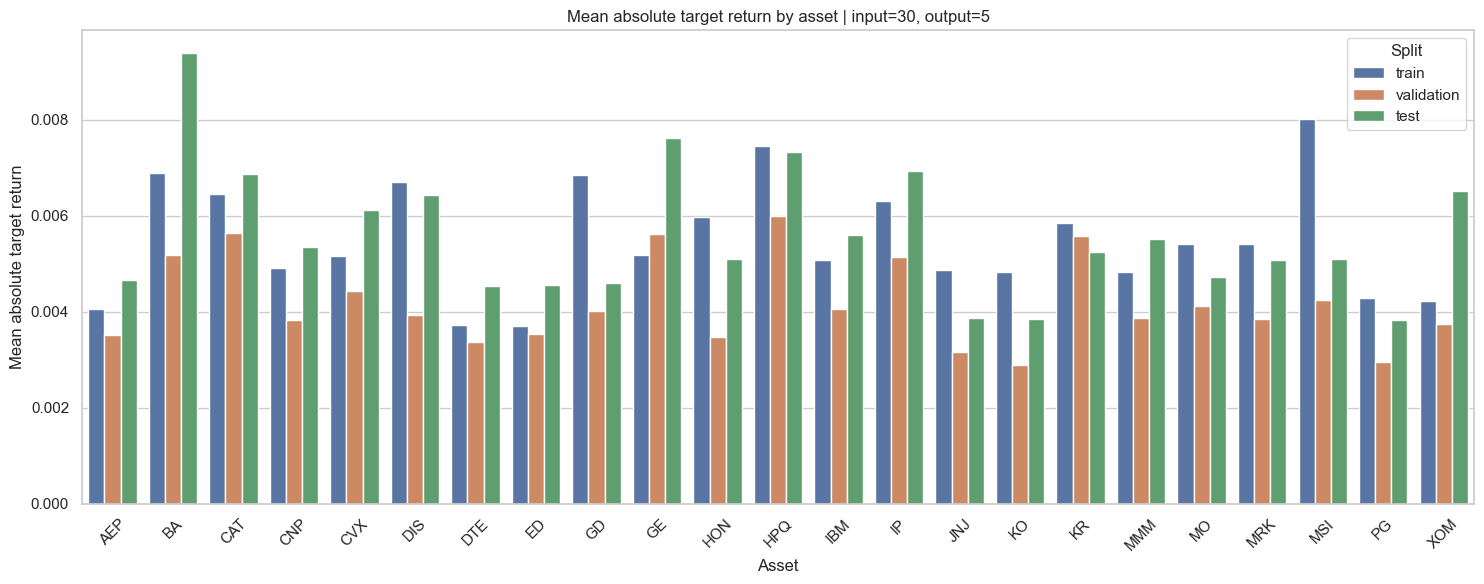

In [6]:
plot_df = (
    by_asset[["train", "validation", "test"]]
    .reset_index()
    .melt(id_vars="asset", var_name="split", value_name="mean_abs_target")
)

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(
    data=plot_df,
    x="asset",
    y="mean_abs_target",
    hue="split",
    hue_order=["train", "validation", "test"],
    ax=ax,
)
ax.set_title(f"Mean absolute target return by asset | input={INPUT_WINDOW}, output={OUTPUT_WINDOW}")
ax.set_xlabel("Asset")
ax.set_ylabel("Mean absolute target return")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Split")
plt.tight_layout()
plt.show()

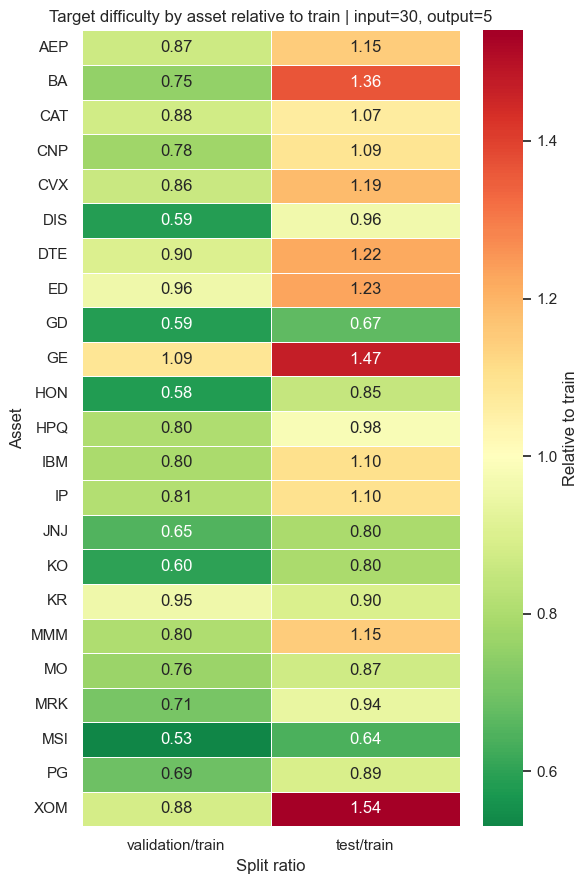

In [7]:
ratio_df = by_asset[["validation/train", "test/train"]].copy()

fig, ax = plt.subplots(figsize=(6, 9))
sns.heatmap(
    ratio_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    center=1.0,
    linewidths=0.5,
    cbar_kws={"label": "Relative to train"},
    ax=ax,
)
ax.set_title(f"Target difficulty by asset relative to train | input={INPUT_WINDOW}, output={OUTPUT_WINDOW}")
ax.set_xlabel("Split ratio")
ax.set_ylabel("Asset")
plt.tight_layout()
plt.show()

## Timeline view

The shaded regions show the chronological splits. The validation region is the last part of the training period, not a random sample.

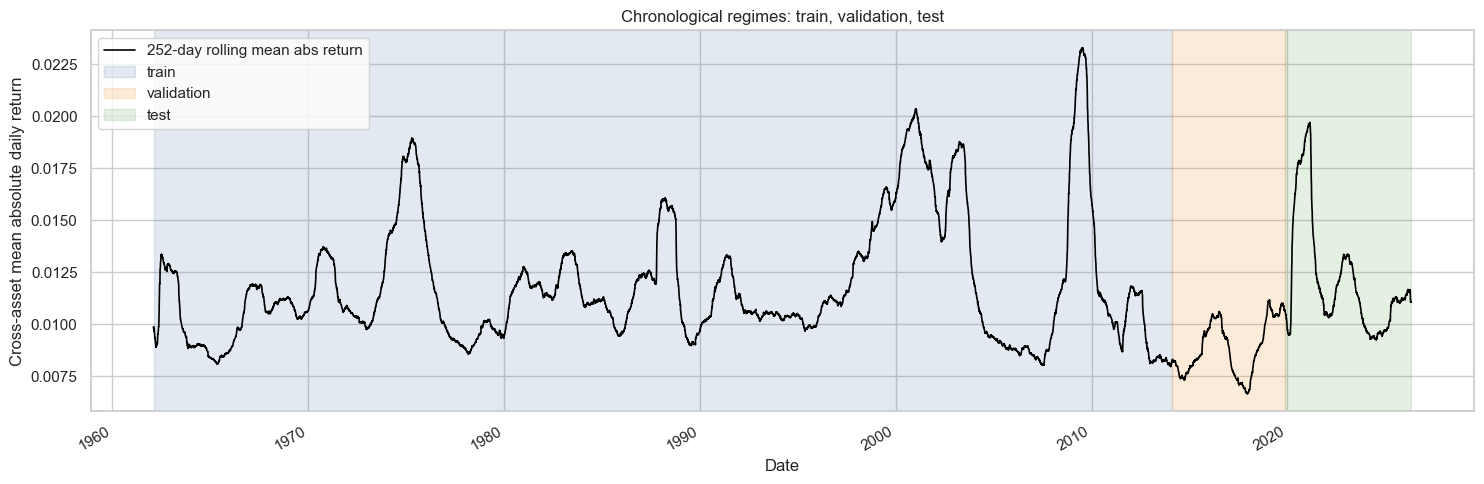

,start,end
split,,
train,1962-02-20,2014-02-07
validation,2014-02-10,2019-11-15
test,2019-11-18,2026-04-24


In [8]:
split_frame = build_split_frame(INPUT_WINDOW, OUTPUT_WINDOW)
periods = split_frame.groupby("split", sort=False).agg(start=("target_end", "min"), end=("target_end", "max"))
periods = periods.reindex(["train", "validation", "test"])

# Cross-sectional average absolute daily return. This is not the model target for
# multi-day outputs, but it shows the market-volatility regime directly over time.
market_abs = RETURNS.abs().mean(axis=1).rename("mean_abs_return")
rolling_market_abs = market_abs.rolling(252, min_periods=30).mean()

fig, ax = plt.subplots(figsize=(15, 5))
rolling_market_abs.plot(ax=ax, color="black", linewidth=1.2, label="252-day rolling mean abs return")
colors = {"train": "#4C78A8", "validation": "#F58518", "test": "#54A24B"}
for split_name, row in periods.iterrows():
    ax.axvspan(row["start"], row["end"], color=colors[split_name], alpha=0.16, label=split_name)

ax.set_title("Chronological regimes: train, validation, test")
ax.set_xlabel("Date")
ax.set_ylabel("Cross-asset mean absolute daily return")
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), loc="upper left")
plt.tight_layout()
plt.show()

periods

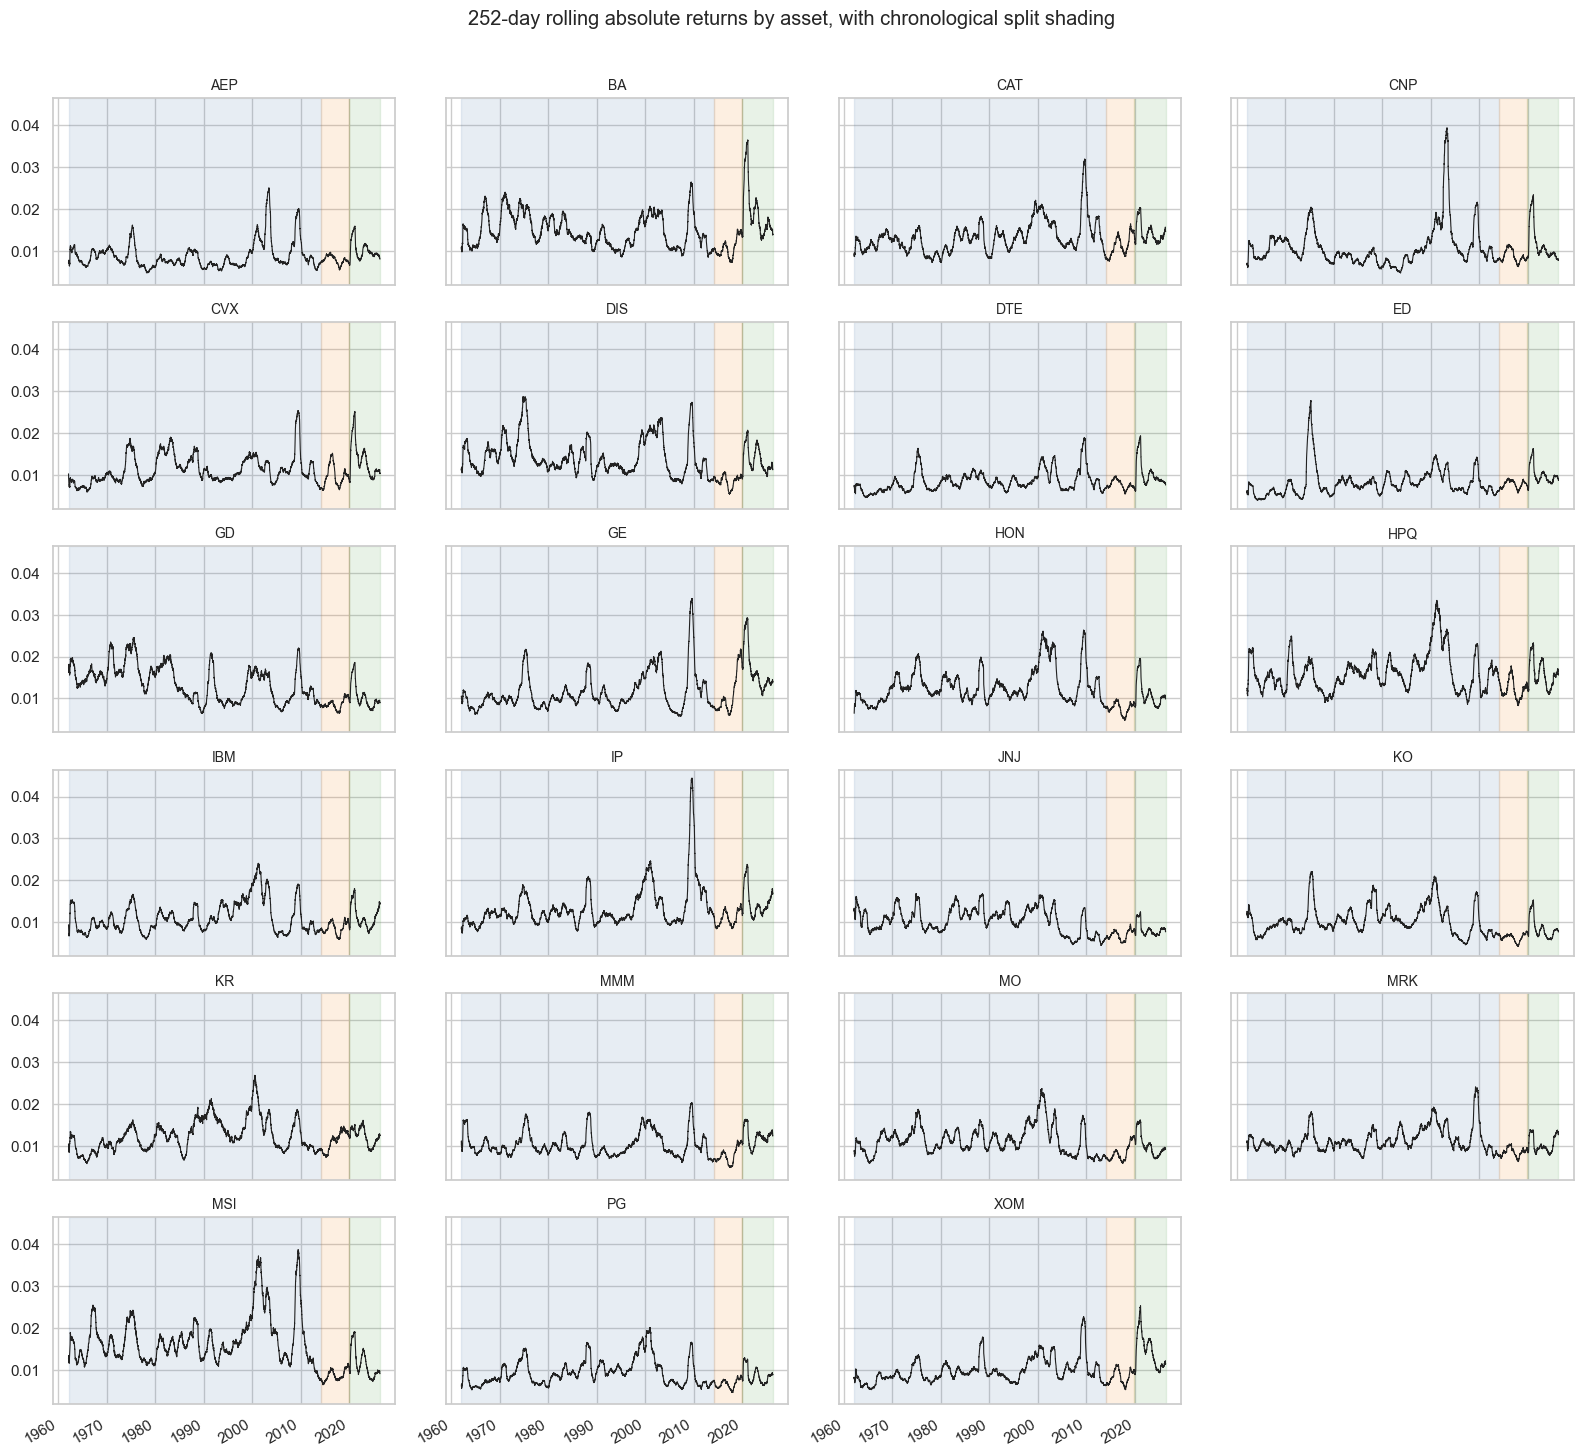

In [9]:
# Small multiples for every asset. These are daily return volatility plots,
# shaded with the same split dates used above.
rolling_assets = RETURNS.abs().rolling(252, min_periods=30).mean()

n_cols = 4
n_rows = int(np.ceil(len(ASSETS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.4 * n_rows), sharex=True, sharey=True)
axes = axes.ravel()

for ax, asset in zip(axes, ASSETS):
    rolling_assets[asset].plot(ax=ax, color="#222222", linewidth=0.8)
    for split_name, row in periods.iterrows():
        ax.axvspan(row["start"], row["end"], color=colors[split_name], alpha=0.13)
    ax.set_title(asset, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(ASSETS):]:
    ax.axis("off")

fig.suptitle("252-day rolling absolute returns by asset, with chronological split shading", y=1.01)
plt.tight_layout()
plt.show()

## Distribution of target magnitudes

This uses the actual model target `y` for the selected window, including all assets.

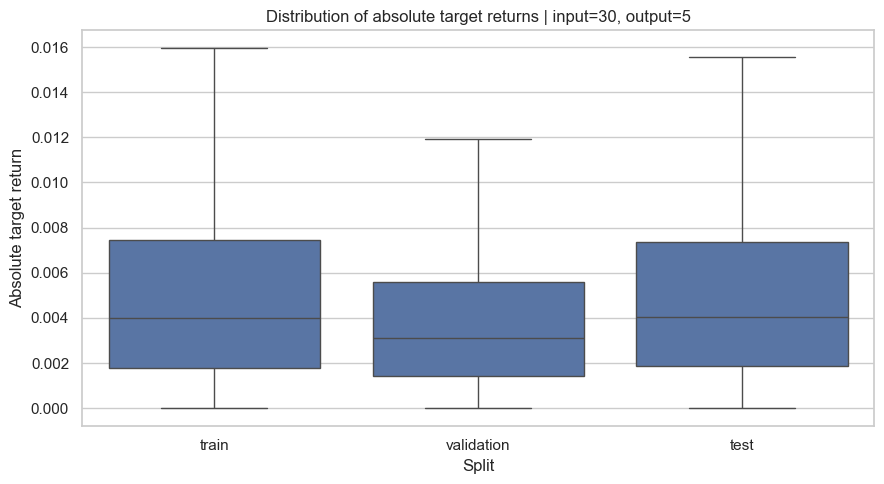

In [10]:
long = build_y_long(INPUT_WINDOW, OUTPUT_WINDOW)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=long,
    x="split",
    y="abs_target_return",
    order=["train", "validation", "test"],
    showfliers=False,
    ax=ax,
)
ax.set_title(f"Distribution of absolute target returns | input={INPUT_WINDOW}, output={OUTPUT_WINDOW}")
ax.set_xlabel("Split")
ax.set_ylabel("Absolute target return")
plt.tight_layout()
plt.show()

## Full window grid

These tables and heatmaps show the same validation-easier effect across the project grid.

In [11]:
window_rows = []
for in_w in INPUT_WINDOWS:
    for out_w in OUTPUT_WINDOWS:
        summary = summarize_split_periods(in_w, out_w)
        train_mean = summary.loc["train", "mean_abs_target"]
        val_mean = summary.loc["validation", "mean_abs_target"]
        test_mean = summary.loc["test", "mean_abs_target"]
        window_rows.append({
            "input_window": in_w,
            "output_window": out_w,
            "train_mean_abs_target": train_mean,
            "validation_mean_abs_target": val_mean,
            "test_mean_abs_target": test_mean,
            "validation/train": val_mean / train_mean,
            "test/train": test_mean / train_mean,
            "train_start": summary.loc["train", "target_start"],
            "train_end": summary.loc["train", "target_end"],
            "validation_start": summary.loc["validation", "target_start"],
            "validation_end": summary.loc["validation", "target_end"],
            "test_start": summary.loc["test", "target_start"],
            "test_end": summary.loc["test", "target_end"],
        })

window_summary = pd.DataFrame(window_rows)

display(
    window_summary.style.format({
        "train_mean_abs_target": "{:.6f}",
        "validation_mean_abs_target": "{:.6f}",
        "test_mean_abs_target": "{:.6f}",
        "validation/train": "{:.3f}",
        "test/train": "{:.3f}",
        "train_start": lambda x: x.date().isoformat(),
        "train_end": lambda x: x.date().isoformat(),
        "validation_start": lambda x: x.date().isoformat(),
        "validation_end": lambda x: x.date().isoformat(),
        "test_start": lambda x: x.date().isoformat(),
        "test_end": lambda x: x.date().isoformat(),
    })
    .background_gradient(subset=["validation/train", "test/train"], cmap="RdYlGn_r")
)

,input_window,output_window,train_mean_abs_target,validation_mean_abs_target,test_mean_abs_target,validation/train,test/train,train_start,train_end,validation_start,validation_end,test_start,test_end
0,5,1,0.011825,0.009050,0.012239,0.765,1.035,1962-01-10,2014-01-31,2014-02-03,2019-11-13,2019-11-14,2026-04-24
1,5,5,0.005482,0.004179,0.005598,0.762,1.021,1962-01-10,2014-02-03,2014-01-29,2019-11-13,2019-11-08,2026-04-24
2,5,30,0.002248,0.001738,0.002358,0.773,1.049,1962-01-10,2014-02-07,2013-12-27,2019-11-15,2019-10-08,2026-04-24
3,5,90,0.001339,0.000987,0.001319,0.738,0.985,1962-01-10,2014-02-25,2013-10-17,2019-11-25,2019-07-23,2026-04-24
4,10,1,0.011826,0.009042,0.012239,0.765,1.035,1962-01-17,2014-02-03,2014-02-04,2019-11-13,2019-11-14,2026-04-24
5,10,5,0.005482,0.004179,0.005598,0.762,1.021,1962-01-17,2014-02-03,2014-01-29,2019-11-13,2019-11-08,2026-04-24
6,10,30,0.002248,0.001739,0.002358,0.773,1.049,1962-01-17,2014-02-10,2013-12-30,2019-11-18,2019-10-09,2026-04-24
7,10,90,0.001339,0.000987,0.001320,0.737,0.986,1962-01-17,2014-02-27,2013-10-21,2019-11-26,2019-07-24,2026-04-24
8,30,1,0.011830,0.009038,0.012243,0.764,1.035,1962-02-14,2014-02-07,2014-02-10,2019-11-15,2019-11-18,2026-04-24
9,30,5,0.005483,0.004179,0.005599,0.762,1.021,1962-02-14,2014-02-07,2014-02-04,2019-11-15,2019-11-12,2026-04-24


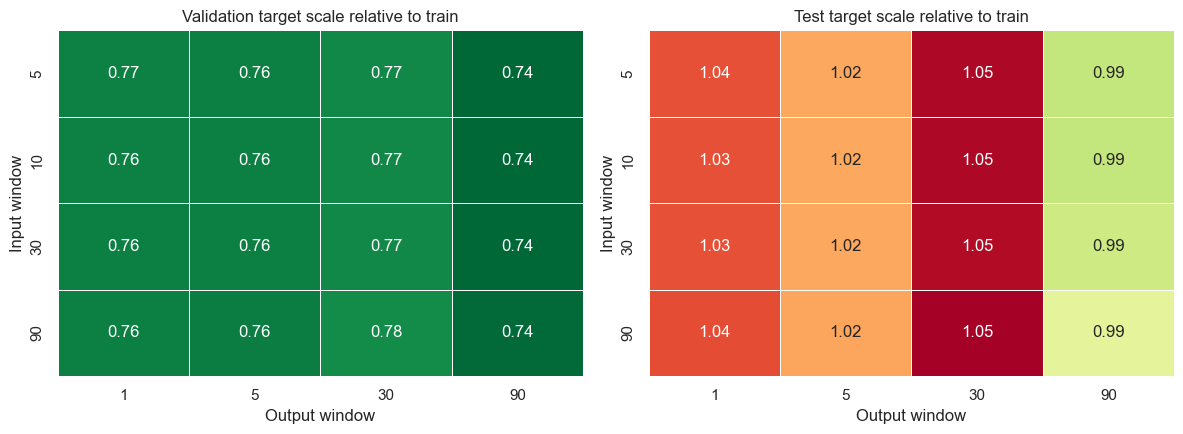

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, metric, title in [
    (axes[0], "validation/train", "Validation target scale relative to train"),
    (axes[1], "test/train", "Test target scale relative to train"),
]:
    mat = window_summary.pivot(index="input_window", columns="output_window", values=metric)
    sns.heatmap(
        mat,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn_r",
        center=1.0,
        linewidths=0.5,
        cbar=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Output window")
    ax.set_ylabel("Input window")

plt.tight_layout()
plt.show()

## Optional: compare with saved model metrics

This does not prove causality by itself, but it helps check that the lower validation loss pattern appears in the saved results.

In [13]:
def load_result_csvs(folder: Path, name: str) -> pd.DataFrame | None:
    if not folder.exists():
        return None
    frames = []
    for path in sorted(folder.glob("*.csv")):
        if path.name.endswith("_history.csv") or "history" in path.parts:
            continue
        try:
            df = pd.read_csv(path)
        except Exception:
            continue
        if {"MAE_train", "MAE_val"}.issubset(df.columns):
            df = df.copy()
            df["source_file"] = path.name
            df["source_group"] = name
            frames.append(df)
    if not frames:
        return None
    return pd.concat(frames, ignore_index=True)

saved_groups = []
for folder, name in [
    (PROJECT_ROOT / "data" / "mlp", "fixed_mlp"),
    (PROJECT_ROOT / "data" / "mlp_search", "mlp_search"),
    (PROJECT_ROOT / "data" / "cnn", "cnn"),
    (PROJECT_ROOT / "data" / "mixtos" / "cnn_rnn_hybrid", "hybrid"),
]:
    loaded = load_result_csvs(folder, name)
    if loaded is not None:
        saved_groups.append(loaded)

if saved_groups:
    saved_results = pd.concat(saved_groups, ignore_index=True)
    saved_results["val_minus_train"] = saved_results["MAE_val"] - saved_results["MAE_train"]
    gap_summary = (
        saved_results.groupby("source_group")
        .agg(
            rows=("source_group", "size"),
            val_below_train=("val_minus_train", lambda s: int((s < 0).sum())),
            mean_val_minus_train=("val_minus_train", "mean"),
            min_val_minus_train=("val_minus_train", "min"),
            max_val_minus_train=("val_minus_train", "max"),
        )
        .sort_values("mean_val_minus_train")
    )
    display(gap_summary.style.format({
        "mean_val_minus_train": "{:.6f}",
        "min_val_minus_train": "{:.6f}",
        "max_val_minus_train": "{:.6f}",
    }))
else:
    print("No saved result CSVs with MAE_train and MAE_val were found.")

,rows,val_below_train,mean_val_minus_train,min_val_minus_train,max_val_minus_train
source_group,,,,,
fixed_mlp,128,110,-0.002041,-0.129351,0.002701
mlp_search,112,111,-0.001252,-0.003752,0.000164
cnn,35,34,-0.001245,-0.002801,-0.000329
hybrid,36,36,-0.001241,-0.002804,-0.000323


## Reading the result

If `validation/train` is below 1, the validation target is smaller in absolute value than the training target. In that case a low validation MAE can come from an easier/lower-volatility validation period.

That is why, for forecasting, a single chronological validation block can be misleading. A better model-selection setup is walk-forward validation or several chronological validation folds across different market regimes.